# BioProtean Lab Workflow for spot detection of smFISH spots

1. Register raw smFISH images.
    Use the merfish3d-analysis package in the Qi2lab GitHub to perform image correction, deconvolution, local and global registration. 
2. Save registered, deconvolved zarr files from the qi2labdatastore as TIFF files.
3. Perform CellPose Segmentation on the registered, z-max-projected polyDT channel. Save as TIFF.
4. Import the above data in BigFISH.
5. Calculate the spot radius using camera metadata.
5. Rescale image. Perform spot detection in BigFISH. Do not perform decomposition.

## Step 5: Spot Detection

Spot detection with BIG FISH can be performed in 2D or 3D

In this notebook, we show examples of **mRNAs detection**. We use 2D images. Three main steps are developed:
- Detection of spots as local maximum.
- Decomposition of dense and bright regions by simulating as many new spots in these regions as possible.
- Detection of clustered spots.

In [1]:
import os
import numpy as np
import bigfish
import bigfish.stack as stack
import bigfish.detection as detection
import bigfish.multistack as multistack
import bigfish.plot as plot
import pandas as pd
import matplotlib.pyplot as plt
from skimage import segmentation
import matplotlib.patches as mpatches
from scipy import ndimage
from pathlib import Path
import psfmodels as psfm
from matplotlib.colors import PowerNorm
from sklearn.metrics import r2_score
print("Big-FISH version: {0}".format(bigfish.__version__))

Big-FISH version: 0.6.2


In [2]:
# Change for your data
data = Path("/data/smFISH/20251028_bartelle_smFISH_mm_microglia_newbuffers")

input_dir = data / "qi2labdatastore" / "big_fish" / "tiffs"
output_dir = data / "qi2labdatastore" / "big_fish" / "results" / "one_tile_2D"
segmentation = data / "qi2labdatastore" / "big_fish" / "segmentation"

metadata = data / "scan_metadata.csv"

# Create output directory if needed
output_dir.mkdir(parents=True, exist_ok=True)


In [3]:
# Load in data 

# Bit 5 is Itgam
# These tiffs are the registered, deconvolved image
path = os.path.join(input_dir, "tile000bit005.ome.tiff")
rna = stack.read_image(path)
print("smfish channel")
print("\r shape: {0}".format(rna.shape))
print("\r dtype: {0}".format(rna.dtype))

# polyDT is our fiducial, or reference marker. This probe labels all polyadenylated RNA and is used for CellPose segmentation.
# We load in this data to visualize the cell boundaries.
path = os.path.join(input_dir, "max_projected_tile000round000corrected_polyDT.ome.tiff")
polyDT_mip = stack.read_image(path)
print("polyDT channel")
print("\r shape: {0}".format(polyDT_mip.shape))
print("\r dtype: {0}".format(polyDT_mip.dtype), "\n")

metadata = pd.read_csv(metadata, index_col=0)

smfish channel
 shape: (63, 2048, 2048)
 dtype: uint16
polyDT channel
 shape: (2048, 2048)
 dtype: uint16 



In [4]:
# Obtain camera metadata
# NA stands for numerical aperture
# provide voxel size in nanometer
na = metadata['na'][0]
z_voxel = metadata['z_voxel_um'][0] * 1000
yx_voxel = metadata['yx_voxel_um'][0] * 1000
yx_voxel = [yx_voxel, yx_voxel]

# Wavelengths of the channels in nanometer
lambda_red = 670 # Alexa647
lambda_yellow = 590 # Atto565

print(na)
print(yx_voxel)
print(z_voxel)

1.35
[np.float64(98.0), np.float64(98.0)]
320.0


In [5]:
# Create a maxiumum intensity projection of the RNA channel

rna_mip = stack.maximum_projection(rna)
print("smfish channel (2D maximum projection)")
print("\r shape: {0}".format(rna_mip.shape))
print("\r dtype: {0}".format(rna_mip.dtype))



rna_mip_rescaled = stack.rescale(rna_mip, channel_to_stretch=None)
print("\r shape: {0}".format(rna_mip_rescaled.shape))

smfish channel (2D maximum projection)
 shape: (2048, 2048)
 dtype: uint16
 shape: (2048, 2048)


## Spot detection

We assume **spot is a local maximum** in the smFISH channel. Three steps are required to detect them:
- Filter the smFISH channel to enhance the signal-to-noise ratio and denoise the image (`bigfish.stack.log_filter`).
- Detect the local maximum in the filtered image (`bigfish.detection.local_maximum_detection`).
- Remove the local maximum under a fixed threshold (`bigfish.detection.spots_thresholding`). To be robust, the thresholding should be applied on the filtered image. Thus, the threshold is set relatively to the filtered image values.
- If necessary, the optimal threshold can be estimated with `bigfish.detection.automated_threshold_setting` (applied on a filtered image).

All these steps are summarized in `bigfish.detection.detect_spots` that return the 2D or 3D coordinates of the detected spots.

#### Note: It is critical that you provide the correct voxel size and spot radius for your camera and your dataset.

In [17]:
voxel_size = yx_voxel 


# Calculated using Abbe’s diffraction formula for lateral (XY) resolution is: d = λ/(2NA)
# Spot radius in this function is likely asking for the radius at the FWHM, so / 2 again
spot_radius = (lambda_yellow / (2 * na))

print(voxel_size)
print(spot_radius)

98.0
218.5185185185185


In [18]:
# Detect spots in 2D
# Does not use the polyDT fiducial channel
spots, threshold = detection.detect_spots(
    images=rna_mip_rescaled, 
    return_threshold=True, 
    voxel_size=voxel_size,  # in nanometer (one value per dimension yx)
    spot_radius=spot_radius)  # in nanometer (one value per dimension yx)

# The function detect_spots returns the coordinates (or list of coordinates) 
# of the spots with shape (nb_spots, 3) or (nb_spots, 2), for 3-d or 2-d images respectively.
print("detected spots")
print("\r shape: {0}".format(spots.shape))
print("\r dtype: {0}".format(spots.dtype))
print("\r threshold: {0}".format(threshold))

detected spots
 shape: (2221, 2)
 dtype: int64
 threshold: 208.0


Given the **voxel size** and the expected **spot radius** (in nanometer), the function `bigfish.detection.detect_spots` automatically estimates a **kernel size** for the LoG filtering and a **minimal distance** between two spots we want to be able to detect separately. It is still possible to set these parameters explicitly in order to fine-tune the detection. Internally, we approximate them as the spot radius in pixel with the function `bigfish.detection.get_object_radius_pixel`.

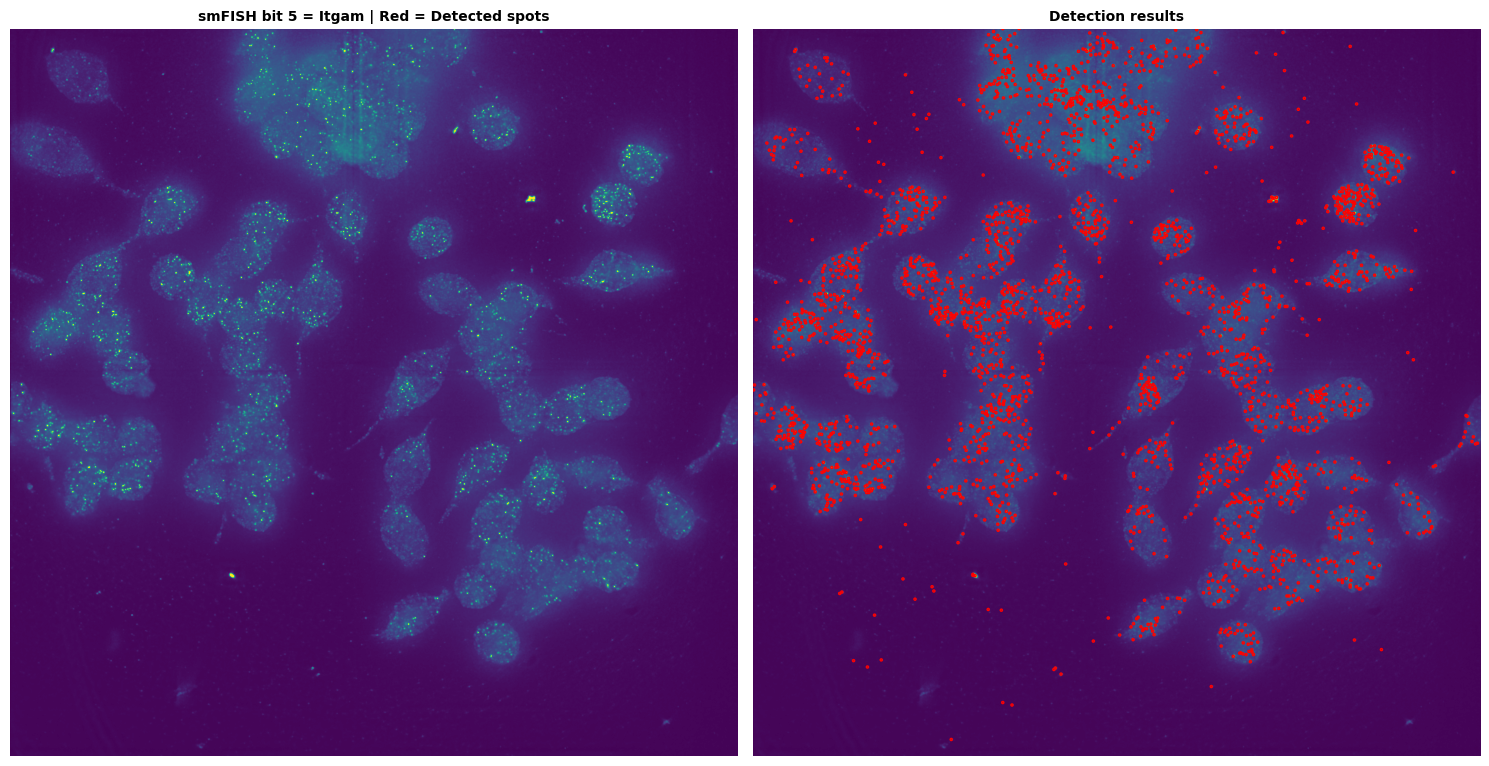

In [10]:
plot.plot_detection(rna_mip, spots, contrast=True, title="smFISH bit 5 = Itgam | Red = Detected spots")

The automated spot detection method tries to find the optimal threshold to discriminate actual spots from noisy blobs. If we plot the number of the spots detected as a function of threshold level we observe an **elbow curve**. The selected threhold is the one located in the breaking point of the curve. This curve can be plotted with `bigfish.plot.plot_elbow`.

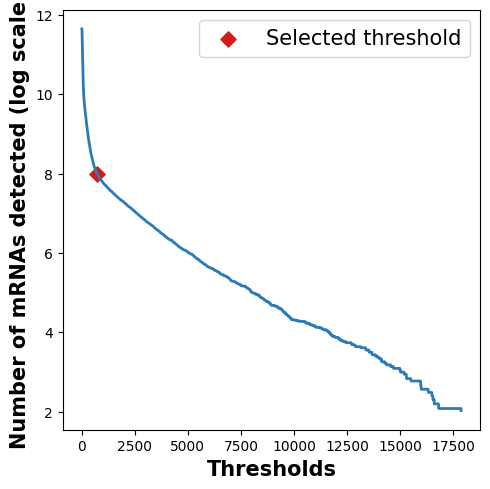

In [11]:
plot.plot_elbow(
    images=rna_mip_rescaled, 
    voxel_size=voxel_size,
    spot_radius=spot_radius)  

In [8]:
# This is an image of just the fiducial beads

beads_data= Path("/data/smFISH/20260316_YGbeads")
beads_path = beads_data / "data_r0001_tile0000_1"

beads = os.path.join(beads_path, "data_r0001_tile0000_NDTiffStack.tif")
beads = stack.read_image(beads)
# beads is a 3D file with format z, y, x
print("\r shape: {0}".format(beads.shape))

beads_mip = stack.maximum_projection(beads)

metadata = beads_data / "scan_metadata.csv"
metadata = pd.read_csv(metadata, index_col=0)

# Camera metadata
na = metadata['na'][0]
yx_voxel = metadata['yx_voxel_um'][0] * 1000
voxel_size = [yx_voxel, yx_voxel]
na = metadata['na'][0]

# Wavelengths of the channels in nanometer
lambda_red = 670 # Alexa647
lambda_yellow = 590 # Atto565

# Calculated using Abbe’s diffraction formula for lateral (XY) resolution is: d = λ/(2NA)
# Spot radius in this function is likely asking for the radius at the FWHM, so / 2 again
spot_radius = (lambda_red / (2 * na)) / 2

print(voxel_size)
print(spot_radius)


 shape: (29, 2048, 2048)
[np.float64(98.0), np.float64(98.0)]
124.07407407407406


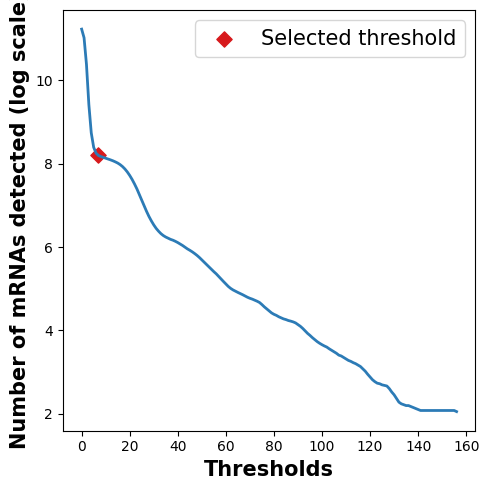

In [13]:
plot.plot_elbow(
    images=beads_mip, 
    voxel_size=voxel_size,
    spot_radius=spot_radius)  

In [14]:
# Compute the median signal to noise ratio
snr = detection.compute_snr_spots(rna_mip, spots, voxel_size=voxel_size, spot_radius=spot_radius)
print(snr)

AttributeError: module 'numpy' has no attribute 'int'.
`np.int` was a deprecated alias for the builtin `int`. To avoid this error in existing code, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

__Note:__ What we call spot radius in this notebook can be understood as its **Point Spread Function (PSF)**. For simplicity sake, this PSF is modelled as a 2D or 3D gaussian.

## Dense region decomposition

In [19]:
spots_post_decomposition, dense_regions, reference_spot = detection.decompose_dense(
    image=rna_mip_rescaled, 
    spots=spots, 
    voxel_size=voxel_size, 
    spot_radius=spot_radius, 
    alpha=0.7,  # alpha impacts the number of spots per candidate region
    beta=1,  # beta impacts the number of candidate regions to decompose
    gamma=5)  # gamma the filtering step to denoise the image
print("detected spots before decomposition")
print("\r shape: {0}".format(spots.shape))
print("\r dtype: {0}".format(spots.dtype), "\n")
print("detected spots after decomposition")
print("\r shape: {0}".format(spots_post_decomposition.shape))
print("\r dtype: {0}".format(spots_post_decomposition.dtype))

detected spots before decomposition
 shape: (2221, 2)
 dtype: int64 

detected spots after decomposition
 shape: (2946, 2)
 dtype: int64


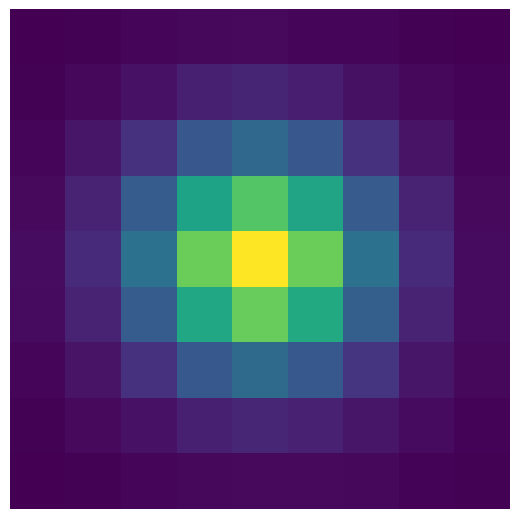

In [20]:
plot.plot_reference_spot(reference_spot, rescale=True)

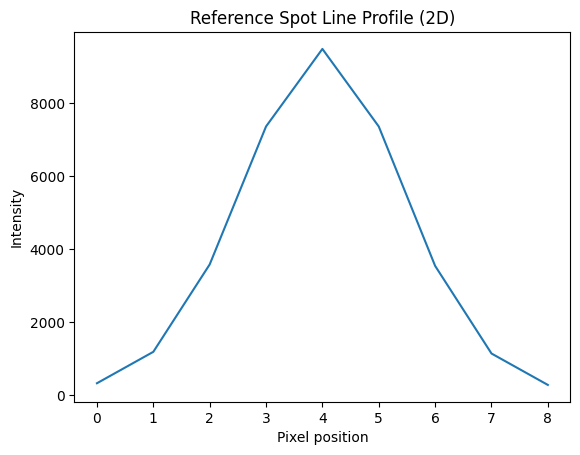

In [21]:
# get center
y_center = reference_spot.shape[0] // 2
x_center = reference_spot.shape[1] // 2

# take horizontal line through center
reference_profile = reference_spot[y_center, :]

x = np.arange(len(reference_profile))

plt.plot(x, reference_profile)
plt.xlabel("Pixel position")
plt.ylabel("Intensity")
plt.title("Reference Spot Line Profile (2D)")
plt.show()

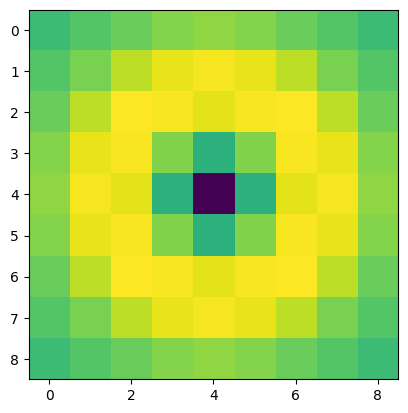

In [22]:
# Model PSF using psfmodels

# number of z planes
nz = 1

# generate centered psf with a point source at `pz` microns from coverslip
# shape will be (5, 5) or )
# dxy = pixel size in sample space (microns)
# dz = axial size in sample space (microns). Only used when `z` is an integer.
# pz = point source z position above the coverslip, in microns.
psf = psfm.make_psf(9, 9, dxy=0.098, dz=0.32, pz=0, model='vectorial')
plt.imshow(psf[nz//2], norm=PowerNorm(gamma=0.4))
plt.show()


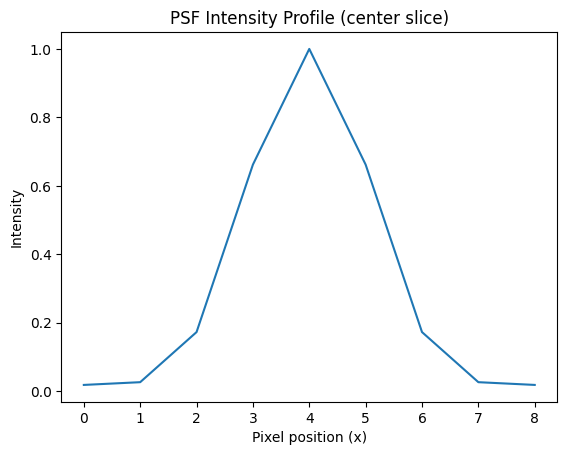

In [23]:
# get central indices
z_center = psf.shape[0] // 2
y_center = psf.shape[1] // 2

# take a line through x at center z and y
psf_profile = psf[z_center, y_center, :]

# x axis = pixel index
x = np.arange(len(psf_profile))

plt.plot(x, psf_profile)
plt.xlabel("Pixel position (x)")
plt.ylabel("Intensity")
plt.title("PSF Intensity Profile (center slice)")
plt.show()

In [24]:
# assume you already extracted:
# psf_profile
# reference_profile

# --- make same length (crop to smallest) ---
min_len = min(len(psf_profile), len(reference_profile))
psf_profile = psf_profile[:min_len]
reference_profile = reference_profile[:min_len]

# --- normalize (0 to 1) ---
def normalize(x):
    return (x - np.min(x)) / (np.max(x) - np.min(x))

psf_norm = normalize(psf_profile)
ref_norm = normalize(reference_profile)

In [25]:
r2 = r2_score(ref_norm, psf_norm)
print(f"R^2 = {r2:.4f}")

R^2 = 0.8938


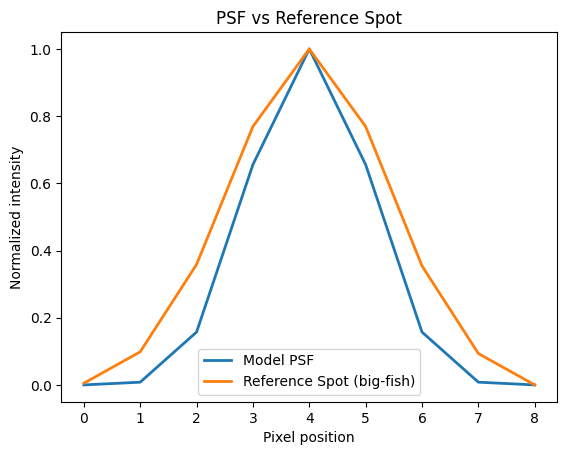

In [26]:
x = np.arange(min_len)

plt.plot(x, psf_norm, label="Model PSF", linewidth=2)
plt.plot(x, ref_norm, label="Reference Spot (big-fish)", linewidth=2)

plt.xlabel("Pixel position")
plt.ylabel("Normalized intensity")
plt.title(f"PSF vs Reference Spot")
plt.legend()
plt.show()

In [ ]:
plot.plot_detection(rna_mip, spots_post_decomposition, contrast=True, title="Detected spots after the decomposition of dense regions")

The image of the **reference spot** can be used for safety checks. Indeed, a bad estimation would lead to a underestimate or overestimate the number of spots in the clusters. Enough samples of individual spots should be available to properly estimate a reference spot. 

## Clusters detection
Two spots are considered connected if they localized within a specific radius (in nanometer). Above a minimum number of connected spots, a cluster can be defined. This detection can be computed with `bigfish.detection.detect_clusters`.

In [ ]:
spots_post_clustering, clusters = detection.detect_clusters(
    spots=spots_post_decomposition, 
    voxel_size=(103, 103), 
    radius=350, 
    nb_min_spots=4)
print("detected spots after clustering")
print("\r shape: {0}".format(spots_post_clustering.shape))
print("\r dtype: {0}".format(spots_post_clustering.dtype), "\n")
print("detected clusters")
print("\r shape: {0}".format(clusters.shape))
print("\r dtype: {0}".format(clusters.dtype))

The function detect_clusters returns the following:

spots_post_clustering contains the coordinates of the detected spots with shape (nb_spots, 4) or (nb_spots, 3). One coordinate per dimension (z,y,x or y,x coordinates) plus the index of the cluster assigned to the spot. If no cluster was assigned, value is -1.

In [ ]:
# plot
# The spots are in red, the clusters are in blue
plot.plot_detection(rna_mip, 
                    spots=[spots_post_decomposition, clusters[:, :2]], 
                    shape=["circle", "polygon"], 
                    radius=[3, 6], 
                    color=["red", "blue"],
                    linewidth=[1, 2], 
                    fill=[False, True], 
                    contrast=True,
                    title='Detected spots after the decomposition and cluster identification',
                    )

## Save results

Spots and foci coordinates can be saved in **npy files** (numpy dedicated format) or **csv files** using functions `bigfish.stack.save_array` and `bigfish.stack.save_data_to_csv` respectively.

In [ ]:
# save in npy files
path = os.path.join(output_dir, "spots.npy")
stack.save_array(spots_post_clustering, path)
path = os.path.join(output_dir, "clusters.npy")
stack.save_array(clusters, path)


# save in csv files
# The header of the csv file is y, x, cluster identity #
spots_df = pd.DataFrame(spots_post_clustering, columns=['y', 'x', 'cluster #'])
path = os.path.join(output_dir, "spots.csv")
stack.save_data_to_csv(spots_df, path, delimiter=',')
path = os.path.join(output_dir, "clusters.csv")
stack.save_data_to_csv(clusters, path, delimiter=',')

## Step 6: Plot Results

From Notebook 6 - Extract cell level results.ipynb

In [ ]:
# Here you see we create the plots using the polyDT maxiumum intensity projection


# stretch the contrast otherwise the spots will be dim and hard to see
polyDT_image_contrasted = stack.rescale(polyDT_mip, channel_to_stretch=0)

image_contrasted = stack.rescale(rna, channel_to_stretch=0)
image_contrasted = stack.maximum_projection(image_contrasted)

Read in segmentation and detection results

In [ ]:
# segmented cells
path = os.path.join(segmentation, "max_projected_tile000round000corrected_polyDT.ome_cp_masks.tif")
cell_label = stack.read_image(path)
print("segmented cells")
print("\r shape: {0}".format(cell_label.shape))
print("\r dtype: {0}".format(cell_label.dtype), "\n")

# detected spots
path = os.path.join(output_dir, "spots.csv")
spots = stack.read_array_from_csv(path, dtype=np.int64, delimiter=',', skiprows=1)
print("detected spots")
print("\r shape: {0}".format(spots.shape))
print("\r dtype: {0}".format(spots.dtype), "\n")

# detected foci
path = os.path.join(output_dir, "clusters.csv")
clusters = stack.read_array_from_csv(path, dtype=np.int64, delimiter=',')
print("detected clusters")
print("\r shape: {0}".format(clusters.shape))
print("\r dtype: {0}".format(clusters.dtype))

In [ ]:
# visuzalize the Cellpose segmentations on top of the polyDT channel

# Create figure and axes
fig, ax = plt.subplots(figsize=(12, 10))

# Display the polyDT_mip image
ax.imshow(polyDT_image_contrasted, cmap='gray')

# Overlay the cellpose segmentation masks as outlines using contour
ax.contour(cell_label, levels=np.unique(cell_label)[1:], colors='red', linewidths=0.5, alpha=0.7)

ax.set_title('PolyDT fiducial channel with Cellpose segmentation masks', fontsize=14)
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')

plt.tight_layout()
plt.show()

In [ ]:
# create the figure with cells numbered

# Create figure and axes
fig, ax = plt.subplots(figsize=(12, 10))

# Display the polyDT_mip image
ax.imshow(polyDT_image_contrasted, cmap='gray')

# Overlay the cellpose segmentation masks as outlines using contour
ax.contour(cell_label, levels=np.unique(cell_label)[1:], colors='red', linewidths=0.5, alpha=0.7)

# Add cell numbers at the centroid of each cell
cell_ids = np.unique(cell_label)
cell_ids = cell_ids[cell_ids != 0]  # Remove background label (0)

for cell_id in cell_ids:
    # Find centroid of the cell
    cell_mask = cell_label == cell_id
    coords = np.where(cell_mask)
    centroid_y = np.mean(coords[0])
    centroid_x = np.mean(coords[1])
    
    # Add text label at centroid
    ax.text(centroid_x, centroid_y, str(int(cell_id)), 
            color='white', fontsize=10, fontweight='bold',
            ha='center', va='center',
            )

ax.set_title('PolyDT fiducial channel with Cellpose segmentation masks (numbered)', fontsize=14)
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')

plt.tight_layout()
plt.show()

In [ ]:
# visuzalize the Cellpose segmentations on top of the Itgam channel

# Create figure and axes
fig, ax = plt.subplots(figsize=(12, 10))

# Display the Itgam channel image
ax.imshow(image_contrasted, cmap='gray')

# Overlay the cellpose segmentation masks as outlines using contour
ax.contour(cell_label, levels=np.unique(cell_label)[1:], colors='red', linewidths=0.5, alpha=0.7)

ax.set_title('Itgam channel', fontsize=14)
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')

plt.tight_layout()
plt.show()

In [ ]:
# visualize the RNA channel with Cellpose segmentations and detected FISH spots

# Create figure and axes
fig, ax = plt.subplots(figsize=(14, 12))

# Display the contrast-enhanced Itgam channel image in grayscale
ax.imshow(image_contrasted, cmap='gray')

# Overlay the cellpose segmentation masks as outlines using contour
ax.contour(cell_label, levels=np.unique(cell_label)[1:], colors='red', linewidths=0.5, alpha=0.7)

# Overlay detected FISH spots
# spots has shape (nb_spots, 3) or (nb_spots, 2), for 3D or 2D images respectively.
# with the columns following the format (y, x) for 2D
spot_y = spots[:, 0]
spot_x = spots[:, 1]

# Plot detected spots as yellow circles (smaller size)
ax.scatter(spot_x, spot_y, c='yellow', s=10, marker='o', 
           edgecolors='white', linewidth=0.3, alpha=0.8, label='Detected spots')

ax.set_title('Itgam channel with Cellpose segmentation and detected FISH spots', fontsize=14)
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

Now, add the code to create the dataframe of spots. This is a work in progress